# Tutorial: GOLEM Knowledge Graph - Fanfiction Metadata & Character Analysis

## Part 1: Exploring Fanfiction Metadata

### Fanfiction Metadata Structure Overview

#### Core Classes
| Class | Note |
|-------|------|
| `crm:E21_Person` | Author |
| `lrm:F1_Work` | Work |
| `lrm:F2_Expression` | Each edition |
| `crm:E54_Dimension` | Numerical indicators (e.g., word count) |
| `lrm:F11_Corporate_Body` | Publisher (e.g., AO3) |
| `crm:E55_Type` | See the Type table |
| `crm:E58_Measurement_Unit` | Classification of numerical indicators |
| `crm:E89_Propositional_Object` | Collection |


#### Type Instances
| Type Instance | Class | Note |
|--------------|-------|------|
| `gt:T000000028` | `crm:E58_Measurement_Unit` | numberOfHits |
| `gt:T000000029` | `crm:E58_Measurement_Unit` | numberOfKudos |
| `gt:T000000030` | `crm:E58_Measurement_Unit` | numberOfComments |
| `gt:T000000031` | `crm:E58_Measurement_Unit` | numberOfBookmarks |
| `gt:T000000032` | `crm:E58_Measurement_Unit` | wordCount |
| `gt:T000000033` | `crm:E58_Measurement_Unit` | numberOfChapters |
| `gt:T000000034` | `crm:E55_Type` | AO3 Tag |
| `gt:T000000035` | `crm:E55_Type` | Content Warning |
| `gt:T000000036` | `crm:E55_Type` | Romantic Category |
| `gt:T000000037` | `crm:E55_Type` | AO3 Tag: Graphic Depictions Of Violence |
| `gt:T000000038` | `crm:E55_Type` | AO3 Tag: Major Character Death |
| `gt:T000000039` | `crm:E55_Type` | Romantic Category: F/M |


#### Object Properties
| Domain | Predicate (inverse predicate) | Range | Note |
|--------|-------------------------------|-------|------|
| `lrm:F1_Work` | `lrm:R3i_realises` (`lrm:R3_is_realised_in`) | `lrm:F2_Expression` | Link Work with Edition |
| `lrm:F2_Expression` | `crm:P43_has_dimension` | `crm:E54_Dimension` | Link Edition with numeric metrics |
| `lrm:F2_Expression` | `schema:creator` | `crm:E21_Person` | Link Edition with author |
| `lrm:F2_Expression` | `schema:keywords` | `crm:E55_Type` | Link Edition with Tags |
| `lrm:F2_Expression` | `schema:publisher` | `lrm:F11_Corporate_Body` | Link Edition with platform |
| `crm:E54_Dimension` | `crm:P2_has_type` | `crm:E58_Measurement_Unit` | Link edition's numeric metrics with classification |
| `lrm:F1_Work` | `schema:collection` | `crm:E89_Propositional_Object` | Link work with collection |
| `crm:E55_Type` | `crm:P127i_has_narrow_term` | `crm:E55_Type` | Type hierarchy |


#### Data Properties
### Data Properties


| Domain                         | Predicate                    | Range         | Note                                                                 |
|--------------------------------|------------------------------|---------------|----------------------------------------------------------------------|
| *(any)*                        | `skos:prefLabel`             | `xsd:string`  | Entity label (preferred label in English)                            |
| `lrm:F2_Expression`           | `schema:abstract`            | `xsd:string`  | Summary or abstract of the edition; links to the intellectual content of a Work |
| `lrm:F2_Expression`           | `schema:contentRating`       | `xsd:string`  | Edition-level rating (e.g., audience rating, maturity level)         |
| `lrm:F2_Expression`           | `schema:creativeWorkStatus`  | `xsd:string`  | Status of the creative work (e.g., Completed, InProgress, Draft)     |
| `lrm:F2_Expression`           | `schema:language`            | `xsd:string`  | Language of the expression (e.g., "en", "fr")                         |
| `lrm:F2_Expression`           | `schema:datePublished`       | `xsd:date`    | First publication date of the edition                                |
| `lrm:F2_Expression`           | `schema:dateModified`        | `xsd:date`    | Last modification date of the edition                                |
| `lrm:F2_Expression`           | `schema:endTime`             | `xsd:date`    | Date when the edition (e.g., a fanfiction) was finished or ended     |
| `crm:E89_Propositional_Object`| `schema:url`                 | URL           | Link to the full content or external page (e.g., AO3 story URL)      |
| `crm:E54_Dimension`           | `crm:P90_has_value`          | `xsd:decimal` | Numerical value for a measurable metric (e.g., word count, kudos)    |

### SPARQL setup


#### Firstly, let's explore the titles and creators of all fanfiction works.
#### You can copy and paste the following query into the [SPARQL endpoint](http://graph-dev.golemlab.eu:8890/sparql).

Define shortcuts (prefixes) for the full path of different IRIs, so that we can refer to elements in a more concise manner by usign the prefixes instead of thefull path of the IRI.

```sparql
PREFIX dlp: <http://www.ontologydesignpatterns.org/ont/dlp/>        # Prefix for ontology design patterns
PREFIX schema: <https://schema.org/>                                 # Prefix for schema.org vocabulary
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>                    # Prefix for CIDOC CRM ontology
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>                # Prefix for LRM (FRBRoo) ontology
PREFIX gc: <https://ontology.golemlab.eu/>                           # Prefix for Golem ontology
PREFIX gd: <https://data.golemlab.eu/entity/>                        # Prefix for Golem entities
PREFIX gt: <https://data.golemlab.eu/entity/type/>                   # Prefix for Golem types

#### Select distinct combinations of work, title and creator
SELECT DISTINCT ?work ?title ?creator
WHERE {
  #### Query from a specific named graph containing Greek fanfiction metadata
  GRAPH <https://golemlab.eu/graph/dh2025Greek10Metadata> {
    # Find entities that are works (F1_Work class)
    ?work a lrm:F1_Work ;
          # Get the work's title
          schema:title ?title ;
          # Link to the work's expression
          lrm:R3i_realises ?expression .
    # Get the creator of the expression
    ?expression schema:creator ?creator .
    # Filter to only include works of type fanfiction (using Golem Lab type)
    ?work crm:P2_has_type gt:T000000014 .  # Filter for fanfiction works
  }
}
LIMIT 10 # Limit results to 10 entries
```

With `SPARQLwrapper` we can save the text of the query into a variable so that we can pass that variable to Python funcions that communicate with the SPARQL enpoint.
The advantage is that we can pass several different queries or we can make queries retrieve some elements (subject, predicate, object) from other source (e.g. a file with work IDs stored on your local computer).

- Connects to a SPARQL endpoint (a web service that allows querying RDF data).

- endpoint_url is the web address where the SPARQL service is hosted.

- SPARQLWrapper is a Python library that helps send queries and retrieve results.

In [3]:
!pip install SPARQLWrapper pandas matplotlib networkx

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/615.4 kB ? eta -:--:--
   --------------- ------------------------ 235.5/615.4 kB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 615.4/615.4 kB 6.4 MB/s eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [19]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [18]:
# Default SSL
ssl_context = ssl.create_default_context()
ssl_context.check_hostname = False
ssl_context.verify_mode = ssl.CERT_NONE

https_handler = urllib.request.HTTPSHandler(context=ssl_context)
opener = urllib.request.build_opener(https_handler)
urllib.request.install_opener(opener)

# Set up SPARQL endpoint
endpoint_url = "https://graph-dev.golemlab.eu/sparql"
sparql = SPARQLWrapper(endpoint_url)
sparql.setTimeout(60)

###Query 1.1: Basic Work Metadata
Retrieve titles and creators of all fanfiction works

Here is how you can save the result of the previous query to a dataframe for further analysis.

In [15]:
sparql_query_1_1 = """
PREFIX dlp: <http://www.ontologydesignpatterns.org/ont/dlp/>
PREFIX schema:<https://schema.org/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX gt: <https://data.golemlab.eu/entity/type/>

SELECT DISTINCT ?work ?title ?creator
WHERE {
  GRAPH <https://golemlab.eu/graph/dh2025Greek10Metadata> {
    ?work a lrm:F1_Work ;
          schema:title ?title ;
          lrm:R3i_realises ?expression .
    ?expression schema:creator ?creator .
    ?work crm:P2_has_type gt:T000000014 .  # Filter for fanfiction works
  }
}
LIMIT 10
"""

Runs a predefined SPARQL query (sparql_query_1_1) and retrieves structured results.
- setQuery() loads the query string.

- setReturnFormat(JSON) ensures results are returned as JSON (a structured data format).

- query().convert() executes the query and converts the response into a Python dictionary.

In [16]:
# Execute Query 1.1
sparql.setQuery(sparql_query_1_1) # Sets the query text
sparql.setReturnFormat(JSON)   # Requests results in JSON format
results = sparql.query().convert()  # Sends the query and fetches results

results

{'head': {'link': [], 'vars': ['work', 'title', 'creator']},
 'results': {'distinct': False,
  'ordered': True,
  'bindings': [{'work': {'type': 'uri',
     'value': 'https://data.golemlab.eu/entity/W000019008'},
    'title': {'type': 'literal', 'value': 'When the Myth is Over'},
    'creator': {'type': 'uri',
     'value': 'https://data.golemlab.eu/entity/A000012573'}},
   {'work': {'type': 'uri',
     'value': 'https://data.golemlab.eu/entity/W000019009'},
    'title': {'type': 'literal', 'value': '(Appearing Like Images of Dreams)'},
    'creator': {'type': 'uri',
     'value': 'https://data.golemlab.eu/entity/A000012574'}},
   {'work': {'type': 'uri',
     'value': 'https://data.golemlab.eu/entity/W000019010'},
    'title': {'type': 'literal', 'value': 'Ugly Beauty And A Restless Love'},
    'creator': {'type': 'uri',
     'value': 'https://data.golemlab.eu/entity/A000012575'}},
   {'work': {'type': 'uri',
     'value': 'https://data.golemlab.eu/entity/W000019011'},
    'title': {'

Transforms raw JSON results into a pandas DataFrame (a tabular structure for easy analysis).

Each result in results["results"]["bindings"] represents a row of data.

The DataFrame columns are Work (ID), Title, and Creator (ID).

In [17]:
# Convert to DataFrame
df_works = pd.DataFrame([{
    "Work": result["work"]["value"].split("/")[-1],# Simplify URI
    "Title": result["title"]["value"],
    "Creator": result["creator"]["value"].split("/")[-1]  # Simplify URI
} for result in results["results"]["bindings"]])

print("Query 1.1 Results - Fanfiction and author")
print(df_works)


Query 1.1 Results - Fanfiction and author
         Work                              Title     Creator
0  W000019008              When the Myth is Over  A000012573
1  W000019009  (Appearing Like Images of Dreams)  A000012574
2  W000019010    Ugly Beauty And A Restless Love  A000012575
3  W000019011              The gods know revenge  A000012576
4  W000019012                     The Face That—  A000012577
5  W000019013                         Who Weeps?  A000012578
6  W000019014                         Twice-Born  A000012579
7  W000019015                        Poplar Tree  A000012580
8  W000019016             A Heavy Responsibility  A000012581
9  W000019017                            Requiem  A000012582


###Query 1.2: Metrics and Tags
Retrieve metrics (kudos, hits) and tags for fanfiction works

You can try this query in the endpoin first:

```sparql
PREFIX schema: <https://schema.org/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX gt: <https://data.golemlab.eu/entity/type/>

SELECT DISTINCT ?work ?expression ?keywordLabel ?dimensionType ?dimensionValue ?dimensionTypeLabel
WHERE {
  # Query from the specific graph containing Greek fanfiction metadata
  GRAPH <https://golemlab.eu/graph/dh2025Greek10Metadata> {
    
    # Find all entities that are works (F1_Work class)
    ?work a lrm:F1_Work .
    
    # Find expressions connected to those works and get their keywords/dimensions
    ?expression lrm:R3_is_realised_in ?work ;          # Link expression to work
                schema:keywords ?keyword ;             # Get associated tags/keywords
                crm:P43_has_dimension ?dimension .     # Get quantitative metrics
    
    # Get the human-readable label for each keyword/tag
    ?keyword skos:prefLabel ?keywordLabel .
    
    # Process dimension/metric information:
    ?dimension a crm:E54_Dimension ;                   # Confirm it's a measurement
               crm:P2_has_type ?dimensionType ;        # What's being measured (e.g., "kudos")
               crm:P90_has_value ?dimensionValue .     # The measurement value
    
    # Get human-readable label for the metric type
    ?dimensionType skos:prefLabel ?dimensionTypeLabel .
  }
}
```

In [22]:
# Define Query 1.2
sparql_query_1_2 = """
PREFIX schema: <https://schema.org/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX gt: <https://data.golemlab.eu/entity/type/>

SELECT DISTINCT ?work ?expression ?dimensionType ?dimensionValue ?dimensionTypeLabel
WHERE {
  GRAPH <https://golemlab.eu/graph/dh2025Greek10Metadata> {
    ?work a lrm:F1_Work .
    ?expression lrm:R3_is_realised_in ?work ;
                crm:P43_has_dimension ?dimension .

    ?dimension a crm:E54_Dimension ;
               crm:P2_has_type ?dimensionType ;
               crm:P90_has_value ?dimensionValue .

    ?dimensionType skos:prefLabel ?dimensionTypeLabel .
  }
}
"""

In [23]:
# Execute Query 1.2
sparql.setQuery(sparql_query_1_2)
sparql.setReturnFormat(JSON)

results = sparql.query().convert()

# Convert to DataFrame
data = []
for result in results["results"]["bindings"]:
    data.append({
        "Work": result["work"]["value"].split("/")[-1],
        "Metric Type": result["dimensionTypeLabel"]["value"],
        "Value": result["dimensionValue"]["value"]
    })

df_metrics = pd.DataFrame(data)
print("\nQuery 1.2 Results - Fanfiction Metrics and Tags:")
print(df_metrics)



Query 1.2 Results - Fanfiction Metrics and Tags:
          Work        Metric Type Value
0   W000019008       numberOfHits    69
1   W000019009       numberOfHits   554
2   W000019010       numberOfHits   505
3   W000019011       numberOfHits   168
4   W000019012       numberOfHits  1558
5   W000019013       numberOfHits   390
6   W000019014       numberOfHits   152
7   W000019015       numberOfHits   208
8   W000019016       numberOfHits   115
9   W000019017       numberOfHits   996
10  W000019008      numberOfKudos     8
11  W000019009      numberOfKudos    18
12  W000019010      numberOfKudos    20
13  W000019011      numberOfKudos     7
14  W000019012      numberOfKudos    81
15  W000019013      numberOfKudos     8
16  W000019014      numberOfKudos     7
17  W000019015      numberOfKudos    14
18  W000019016      numberOfKudos     5
19  W000019017      numberOfKudos    42
20  W000019008   numberOfComments     3
21  W000019009   numberOfComments     6
22  W000019010   numberOfComme

In [24]:
# Pivot the DataFrame to wide format
df_wide = df_metrics.pivot(
    index='Work',          # Rows will be unique works
    columns='Metric Type',  # Columns will be metric types
    values='Value'         # Values will be the metric values
).reset_index()            # Reset index to make Work a column again

column_order = [
    'Work',
    'numberOfHits',
    'numberOfKudos',
    'numberOfComments',
    'numberOfBookmarks',
    'wordCount',
    'numberOfChapters'
]

# Select and reorder columns, filling any missing values with 0
df_wide = df_wide.reindex(columns=column_order).fillna(0)

# Convert metric values from string to numeric (since SPARQL returns strings)
for col in df_wide.columns[1:]:  # Skip the 'Work' column
    df_wide[col] = pd.to_numeric(df_wide[col])

print("\nFanfiction Metrics in Wide Format:")
print(df_wide)


Fanfiction Metrics in Wide Format:
Metric Type        Work  numberOfHits  numberOfKudos  numberOfComments  \
0            W000019008            69              8                 3   
1            W000019009           554             18                 6   
2            W000019010           505             20                 2   
3            W000019011           168              7                 2   
4            W000019012          1558             81                 8   
5            W000019013           390              8                 5   
6            W000019014           152              7                 5   
7            W000019015           208             14                 6   
8            W000019016           115              5                 3   
9            W000019017           996             42                 3   

Metric Type  numberOfBookmarks  wordCount  numberOfChapters  
0                            4        400                 1  
1                        

###Query 1.3: Fanfiction Publication Year Distribution
Retrieve the publication year for all fanfiction works and visualize the distribution of stories published per year. You can try this query in the endpoint.

```sparql
PREFIX schema: <https://schema.org/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX gt: <https://data.golemlab.eu/entity/type/>

# Select publication years and count of works per year
SELECT ?publishYear (COUNT(?work) as ?count)
WHERE {
  # Query from the Greek fanfiction metadata graph
  GRAPH <https://golemlab.eu/graph/dh2025Greek10Metadata> {
    # Find all works (F1_Work class)
    ?work a lrm:F1_Work ;
          # Get the expressions that realize these works
          lrm:R3i_realises ?expression .
    
    # Get the publication date of each expression
    ?expression schema:datePublished ?date .

    # Extract just the year from the full date (converts to xsd:date first)
    BIND(YEAR(xsd:date(?date)) AS ?publishYear)

    # Filter to only include works marked as fanfiction (type T000000014)
    ?work crm:P2_has_type gt:T000000014 .
  }
}
# Group results by publication year
GROUP BY ?publishYear
# Sort chronologically by year
ORDER BY ?publishYear
```

In [27]:
sparql_query_1_3 = """
PREFIX schema: <https://schema.org/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX gt: <https://data.golemlab.eu/entity/type/>

SELECT ?publishYear (COUNT(?work) as ?count)
WHERE {
  GRAPH <https://golemlab.eu/graph/dh2025Greek10Metadata> {
    ?work a lrm:F1_Work ;
          lrm:R3i_realises ?expression .
    ?expression schema:datePublished ?date .

    # Extract year from date
    BIND(YEAR(xsd:date(?date)) AS ?publishYear)

    # Filter for fanfiction works
    ?work crm:P2_has_type gt:T000000014 .
  }
}
GROUP BY ?publishYear
ORDER BY ?publishYear
"""
# Execute and process results
sparql.setQuery(sparql_query_1_3)
results = sparql.query().convert()

# Convert to DataFrame
data = []
for result in results["results"]["bindings"]:
    data.append({
        "Year": int(result["publishYear"]["value"]),
        "Count": int(result["count"]["value"])
    })

df_years = pd.DataFrame(data)
df_years

,Year,Count
0,2004,1
1,2010,2
2,2020,1
3,2022,3
4,2024,3


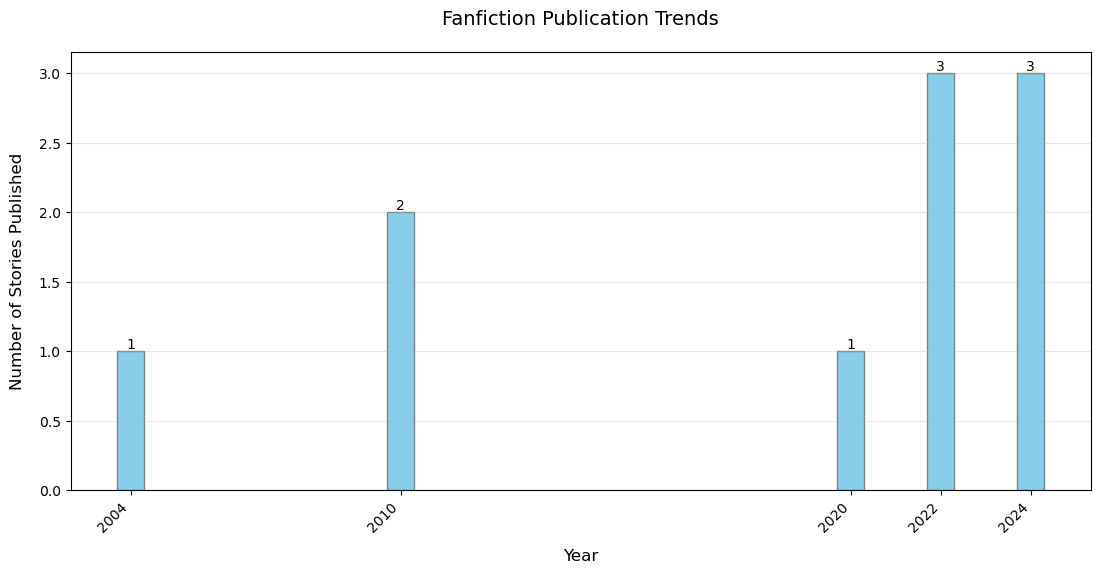

In [28]:
# Visualization - Bar Chart (Improved)
plt.figure(figsize=(12, 6))

# Convert years to integers for proper display
years = df_years['Year'].astype(int)
counts = df_years['Count']

# Create bars with consistent width
bars = plt.bar(years, counts, width=0.6, color='skyblue', edgecolor='grey')

# Customize the chart
plt.title('Fanfiction Publication Trends', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Number of Stories Published', fontsize=12, labelpad=10)
plt.grid(axis='y', alpha=0.3)

# Set x-axis to show integer years only
plt.xticks(years, rotation=45, ha='right')

# Add value labels centered on each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom',
             fontsize=10)

# Adjust margins to prevent clipping
plt.subplots_adjust(bottom=0.15, left=0.1, right=0.95)

plt.show()

###Query 1.4: Popular Fanfiction Works

Identify popular fanfiction works with more than 30 kudos and 300 hits, displaying their titles, publication years, and engagement metrics.

In [29]:
sparql_query_1_4 = """
PREFIX schema: <https://schema.org/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX gt: <https://data.golemlab.eu/entity/type/>

SELECT ?title ?publishYear ?hits ?kudos
WHERE {
  GRAPH <https://golemlab.eu/graph/dh2025Greek10Metadata> {
    ?work a lrm:F1_Work ;
          schema:title ?title ;
          lrm:R3i_realises ?expression .

    ?expression schema:datePublished ?date ;
                crm:P43_has_dimension ?hitsDim ;
                crm:P43_has_dimension ?kudosDim .

    # Get hits dimension
    ?hitsDim crm:P2_has_type gt:T000000028 ; # numberOfHits
             crm:P90_has_value ?hits .

    # Get kudos dimension
    ?kudosDim crm:P2_has_type gt:T000000029 ; # numberOfKudos
              crm:P90_has_value ?kudos .

    # Extract year from date
    BIND(YEAR(xsd:date(?date)) AS ?publishYear)

    # Filter criteria
    FILTER(?kudos > 30 && ?hits > 300)
    ?work crm:P2_has_type gt:T000000014 .  # Fanfiction filter
  }
}
ORDER BY DESC(?kudos)
"""

# Execute and process results
sparql.setQuery(sparql_query_1_4)
results = sparql.query().convert()

# Convert to DataFrame
data = []
for result in results["results"]["bindings"]:
    data.append({
        "Title": result["title"]["value"],
        "Year": int(result["publishYear"]["value"]),
        "Hits": int(result["hits"]["value"]),
        "Kudos": int(result["kudos"]["value"])
    })

df_popular = pd.DataFrame(data)
print("Popular Fanfiction Works (Kudos > 30, Hits > 300):")
df_popular

Popular Fanfiction Works (Kudos > 30, Hits > 300):


,Title,Year,Hits,Kudos
0,The Face That—,2010,1558,81
1,Requiem,2004,996,42


###Query 1.5: Tag Analysis
Analyze romantic categories and content warnings across all fanfiction works.

In [30]:
sparql_query_1_5_final = """
PREFIX schema: <https://schema.org/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX gt: <https://data.golemlab.eu/entity/type/>

SELECT DISTINCT ?title ?tagLabel ?categoryType
WHERE {
  GRAPH <https://golemlab.eu/graph/dh2025Greek10Metadata> {
    # Get all fanfiction works
    ?work a lrm:F1_Work ;
          schema:title ?title ;
          crm:P2_has_type gt:T000000014 ;  # Filter for fanfiction
          lrm:R3i_realises ?expression .

    # Get tags for the work
    ?expression schema:keywords ?tag .

    # Get the text label of the tag
    ?tag skos:prefLabel ?tagLabel .

    {
      # Content warning tags (subclass of T000000035)
      ?tag crm:P127i_has_narrow_term gt:T000000035 .
      BIND("Content Warning" AS ?categoryType)
    }
    UNION
    {
      # Romantic category tags (subclass of T000000036)
      ?tag crm:P127i_has_narrow_term gt:T000000036 .
      BIND("Romantic Category" AS ?categoryType)
    }
  }
}
ORDER BY ?title
"""

# Execute the query
sparql.setQuery(sparql_query_1_5_final)
results = sparql.query().convert()

# Process results and transform to desired format
from collections import defaultdict

work_data = defaultdict(lambda: {
    "Title": "",
    "Content Warnings": [],
    "Romantic Categories": []
})

for result in results["results"]["bindings"]:
    title = result["title"]["value"]
    tag = result["tagLabel"]["value"]
    category = result["categoryType"]["value"]

    work_data[title]["Title"] = title
    if category == "Content Warning":
        work_data[title]["Content Warnings"].append(tag)
    else:
        work_data[title]["Romantic Categories"].append(tag)

# Convert to DataFrame and clean up empty lists
data = []
for work in work_data.values():
    data.append({
        "Title": work["Title"],
        "Content Warnings": ", ".join(work["Content Warnings"]) if work["Content Warnings"] else "None",
        "Romantic Categories": ", ".join(work["Romantic Categories"]) if work["Romantic Categories"] else "None"
    })

df_tags = pd.DataFrame(data)
print("Final Query 1.5 Results (Separate Columns):")
df_tags

Final Query 1.5 Results (Separate Columns):


,Title,Content Warnings,Romantic Categories
0,(Appearing Like Images of Dreams),"Major Character Death, Graphic Depictions Of V...",Gen
1,A Heavy Responsibility,Major Character Death,Gen
2,Poplar Tree,None,F/M
3,Requiem,Major Character Death,M/M
4,The Face That—,Major Character Death,Gen
5,The gods know revenge,"Underage Sex, Major Character Death, Graphic D...",F/M
6,Twice-Born,"Graphic Depictions Of Violence, Major Characte...",F/M
7,Ugly Beauty And A Restless Love,"Major Character Death, Underage Sex, Graphic D...","Multi, F/M"
8,When the Myth is Over,Major Character Death,F/M
9,Who Weeps?,"Major Character Death, Rape/Non-Con",F/M


## Part 2: Character Modeling and Analysis

### Character Ontology Overview
The GOLEM ontology models characters as evolving narrative entities whose identities, traits, and relationships transform across canonical and fan-generated texts. Its two-level character modeling strategy:
- **G1 Character**: Individual character instantiations
- **G0 Character-Stoff**: Broader conceptual entities spanning instances


#### Core Character Classes
| Class | Note |
|-------|------|
| `gc:G0_Character-Stoff` | Abstract character concept spanning instances |
| `gc:G1_Character` | Specific character in a work |
| `gc:G17_Character_Feature` | Character traits/attributes |
| `gc:G4_Social_Relationship` | Relationships between characters |
| `gc:G6_Relationship_Role` | Relationship Role of characters |
| `gc:G11_Narrative_Role` | Character roles in narratives |
| `gc:G5_Narrative_Event` | Story events involving characters |
| `gc:G7_Narrative_Sequence` | Sequences of narrative events |


#### Character Property Relationships
| Domain | Predicate | Range | Note |
|--------|-----------|-------|------|
| `gc:G1_Character` | `gc:GP1_is_character_in` | `lrm:F1_Work` | Links character to work |
| `gc:G1_Character` | `crm:P130_shows_features_of` | `gc:G0_Character-Stoff` | Links instance to abstract concept |
| `gc:G1_Character` | `dlp:plays` | `gc:G11_Narrative_Role` | Character's narrative role |
| `gc:G1_Character` | `dlp:participant-in` | `gc:G5_Narrative_Event` | Character participation in events |
| `gc:G1_Character` | `gc:GP0_has_feature` | `gc:G17_Character_Feature` | Character traits |
| `gc:G4_Social_Relationship` | `dlp:involves` | `gc:G1_Character` | Relationships between characters |

#### Narrative Role Examples
| Role Instance | Class | Note |
|---------------|-------|------|
| `gd:NR00000001` | `gc:G11_Narrative_Role` | Victim role |
| `gd:NR00000002` | `gc:G11_Narrative_Role` | Perpetrator role |

#### Character Feature Types
| Type Instance | Class | Note |
|---------------|-------|------|
| `gt:BIO0000000` | `crm:E55_Type` | Biographical features |
| `gt:PHY0000000` | `crm:E55_Type` | Physical characteristics |
| `gt:PSY0000000` | `crm:E55_Type` | Psychological features |
| `gt:BIOGE00000` | `crm:E55_Type` | Gender (broader term for gender types) |

> **Note on Named Graph**: Part 2 queries use the graph `<https://golemlab.eu/graph/Greek10_Character_Module_Demo>`, which contains the character module data for the 10 Greek mythology fanfiction works.

### 2.1 Character Appearance in Fanfiction (CQ1)
List all the characters in the KG and the fanfiction works that include them.

This query identifies characters in works marked as fanfiction (`gt:T000000014`) and returns their names along with the story titles. It uses the **Character Module Demo** graph.

In [31]:
# CQ1: List all characters and the fanfiction works that include them
sparql_query_2_1 = """
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX dlp: <http://www.ontologydesignpatterns.org/ont/dlp/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX gt: <https://data.golemlab.eu/entity/type/>
PREFIX schema: <https://schema.org/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

SELECT DISTINCT ?storyTitle ?characterLabel
WHERE {
  GRAPH <https://golemlab.eu/graph/Greek10_Character_Module_Demo> {
    ?story a lrm:F1 ;
           crm:P2_has_type gt:T000000014 ;  # fanFiction
           schema:title ?storyTitle .
    ?character gc:GP1_is_character_in ?story ;
               skos:prefLabel ?characterLabel .
  }
}
ORDER BY ?storyTitle
"""

# Execute the query
sparql.setQuery(sparql_query_2_1)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data = []
for result in results["results"]["bindings"]:
    data.append({
        "Story Title": result["storyTitle"]["value"],
        "Character": result["characterLabel"]["value"]
    })

df_characters = pd.DataFrame(data)
print("\nCharacters in Fanfiction Works:")
df_characters


Characters in Fanfiction Works:


,Story Title,Character
0,(Appearing Like Images of Dreams),Clytaemnestra
1,(Appearing Like Images of Dreams),Cassandra
2,A Heavy Responsibility,Teucer
3,A Heavy Responsibility,Ajax
4,A Heavy Responsibility,Eurysaces
5,Poplar Tree,Hades
6,Poplar Tree,Leuce
7,Requiem,Achilles
8,Requiem,Paris
9,Requiem,Hector


In [32]:
df_characters_aggregated = df_characters.groupby('Story Title')['Character'] \
                                      .apply(lambda x: ', '.join(x)) \
                                      .reset_index()

print("\nCharacters in Fanfiction Works (Aggregated):")
df_characters_aggregated


Characters in Fanfiction Works (Aggregated):


,Story Title,Character
0,(Appearing Like Images of Dreams),"Clytaemnestra, Cassandra"
1,A Heavy Responsibility,"Teucer, Ajax, Eurysaces"
2,Poplar Tree,"Hades, Leuce"
3,Requiem,"Achilles, Paris, Hector, Patroclus"
4,The Face That—,"Achilles, Paris, Hector, Helen"
5,The gods know revenge,"Oenone, Paris"
6,Twice-Born,"Semele, Zeus, Dionysus"
7,Ugly Beauty And A Restless Love,"Demeter, Zeus, Persephone"
8,When the Myth is Over,"Eurydice, Maenads, Orpheus, Dionysus"
9,Who Weeps?,"wild pig, Cinyras, Aphrodite, Adonis, Myrrha"


### 2.2 Character Death Analysis (CQ2)
Who dies in the fanfiction stories?

This query identifies characters who play the **victim role** (`gd:NR00000001`) in fanfiction works, returning their names, the narrative role label, and the story title.

In [33]:
# CQ2: Who dies in the fanfiction stories?
sparql_query_2_2 = """
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX dlp: <http://www.ontologydesignpatterns.org/ont/dlp/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX gt: <https://data.golemlab.eu/entity/type/>
PREFIX schema: <https://schema.org/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

SELECT DISTINCT ?storyTitle ?characterLabel ?narrativeRoleLabel
WHERE {
  GRAPH <https://golemlab.eu/graph/Greek10_Character_Module_Demo> {
    ?story a lrm:F1 ;
           crm:P2_has_type gt:T000000014 ;  # fanFiction
           schema:title ?storyTitle .
    ?character gc:GP1_is_character_in ?story ;
               skos:prefLabel ?characterLabel ;
               dlp:plays gd:NR00000001 .    # victim role
    gd:NR00000001 skos:prefLabel ?narrativeRoleLabel .
  }
}
ORDER BY ?storyTitle
"""

sparql.setQuery(sparql_query_2_2)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data = []
for result in results["results"]["bindings"]:
    data.append({
        "Story Title": result["storyTitle"]["value"],
        "Character": result["characterLabel"]["value"],
        "Narrative Role": result["narrativeRoleLabel"]["value"]
    })

df_deaths = pd.DataFrame(data)
print("\nCharacters Who Die in Fanfiction Stories:")
df_deaths


Characters Who Die in Fanfiction Stories:


,Story Title,Character,Narrative Role
0,(Appearing Like Images of Dreams),Cassandra,victim
1,A Heavy Responsibility,Ajax,victim
2,Poplar Tree,Leuce,victim
3,Requiem,Patroclus,victim
4,Requiem,Hector,victim
5,The Face That—,Hector,victim
6,The gods know revenge,Paris,victim
7,Twice-Born,Semele,victim
8,Ugly Beauty And A Restless Love,Persephone,victim
9,When the Myth is Over,Orpheus,victim


### 2.3 Perpetrator Analysis (CQ3)
Who kills the deceased characters?

This query links victims (`gd:NR00000001`) and perpetrators (`gd:NR00000002`) through shared narrative events within narrative sequences (`gc:G7_Narrative_Sequence`), showing who kills whom in each story.

In [34]:
# CQ3: Who kills the deceased characters?
sparql_query_2_3 = """
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX dlp: <http://www.ontologydesignpatterns.org/ont/dlp/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX gt: <https://data.golemlab.eu/entity/type/>
PREFIX schema: <https://schema.org/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>

SELECT DISTINCT ?victimLabel ?victimRoleLabel ?perpetratorLabel ?perpetratorRoleLabel ?sequenceLabel
WHERE {
  GRAPH <https://golemlab.eu/graph/Greek10_Character_Module_Demo> {
    # Find fanfiction stories
    ?story a lrm:F1 ;
           crm:P2_has_type gt:T000000014 .  # fanFiction
    
    # Find narrative sequences in these stories
    ?narrativeSequence a gc:G7_Narrative_Sequence ;
                       dlp:sequences ?deathEvent ;
                       skos:prefLabel ?sequenceLabel .
    
    # Victim participates in death event
    ?victim dlp:participant-in ?deathEvent ;
            dlp:plays gd:NR00000001 ;        # victim role
            skos:prefLabel ?victimLabel .
    gd:NR00000001 skos:prefLabel ?victimRoleLabel .
    
    # Perpetrator participates in same death event
    ?perpetrator dlp:participant-in ?deathEvent ;
                 dlp:plays gd:NR00000002 ;   # perpetrator role
                 skos:prefLabel ?perpetratorLabel .
    gd:NR00000002 skos:prefLabel ?perpetratorRoleLabel .
    
    # Ensure both characters are in the same story
    ?victim gc:GP1_is_character_in ?story .
    ?perpetrator gc:GP1_is_character_in ?story .
  }
}
ORDER BY ?sequenceLabel ?victimLabel
"""

sparql.setQuery(sparql_query_2_3)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data = []
for result in results["results"]["bindings"]:
    data.append({
        "Victim": result["victimLabel"]["value"],
        "Victim Role": result["victimRoleLabel"]["value"],
        "Perpetrator": result["perpetratorLabel"]["value"],
        "Perpetrator Role": result["perpetratorRoleLabel"]["value"],
        "Narrative Sequence": result["sequenceLabel"]["value"]
    })

df_killer = pd.DataFrame(data)
print("\nVictim–Perpetrator Pairs:")
df_killer


Victim–Perpetrator Pairs:


,Victim,Victim Role,Perpetrator,Perpetrator Role,Narrative Sequence
0,Adonis,victim,wild pig,perpetrator,Adonis's death by the boar
1,Ajax,victim,Ajax,perpetrator,Ajax's suicide
2,Cassandra,victim,Clytaemnestra,perpetrator,Cassandra's death in the palace
3,Hector,victim,Achilles,perpetrator,Hector's death in battle
4,Hector,victim,Hector,perpetrator,Hector's death in battle
5,Orpheus,victim,Maenads,perpetrator,Killing of Orpheus by the Maenads
6,Myrrha,victim,Cinyras,perpetrator,Myrrha's transformation and death
7,Paris,victim,Oenone,perpetrator,Paris's death and Oenone's rejection
8,Hector,victim,Hector,perpetrator,Patroclus's death
9,Patroclus,victim,Hector,perpetrator,Patroclus's death


### 2.4 Romantic Relationships of Deceased Characters (CQ4)
Who is romantically linked to the deceased?

The GOLEM ontology models social relationships via `gc:G4_Social_Relationship`. This query finds romantic relationships (`gt:T000000007`) involving characters who play the victim role across fanfiction works.

In [35]:
# CQ4: Who is romantically linked to the deceased?
sparql_query_2_4 = """
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX dlp: <http://www.ontologydesignpatterns.org/ont/dlp/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX gt: <https://data.golemlab.eu/entity/type/>
PREFIX schema: <https://schema.org/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>

SELECT DISTINCT ?victimLabel ?victimRoleLabel ?loverLabel ?relationshipTypeLabel ?storyTitle
WHERE {
  GRAPH <https://golemlab.eu/graph/Greek10_Character_Module_Demo> {
    # Victim character
    ?victim dlp:plays gd:NR00000001 ;         # victim role
            skos:prefLabel ?victimLabel ;
            gc:GP1_is_character_in ?story .
    gd:NR00000001 skos:prefLabel ?victimRoleLabel .
    
    # Fanfiction story
    ?story a lrm:F1 ;
           schema:title ?storyTitle ;
           crm:P2_has_type gt:T000000014 .   # fanFiction

    # Romantic relationship involving victim
    ?relationship a gc:G4_Social_Relationship ;
                  dlp:involves ?victim ;
                  dlp:involves ?lover ;
                  dlp:d-uses ?relationshipRole .
    FILTER(?victim != ?lover)
    
    # Relationship type: romantic/erotic
    ?relationshipRole crm:P2_has_type gt:T000000007 ;
                      skos:prefLabel ?relationshipTypeLabel .
    
    ?lover skos:prefLabel ?loverLabel .
  }
}
ORDER BY ?storyTitle ?victimLabel
"""

sparql.setQuery(sparql_query_2_4)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data = []
for result in results["results"]["bindings"]:
    data.append({
        "Victim": result["victimLabel"]["value"],
        "Victim Role": result["victimRoleLabel"]["value"],
        "Lover": result["loverLabel"]["value"],
        "Relationship Type": result["relationshipTypeLabel"]["value"],
        "Story": result["storyTitle"]["value"]
    })

df_relationships = pd.DataFrame(data)
print("\nRomantic Relationships Involving Deceased Characters:")
df_relationships


Romantic Relationships Involving Deceased Characters:


,Victim,Victim Role,Lover,Relationship Type,Story
0,Leuce,victim,Hades,beloved,Poplar Tree
1,Leuce,victim,Hades,lover,Poplar Tree
2,Hector,victim,Paris,lover,Requiem
3,Paris,victim,Oenone,lover,The gods know revenge
4,Semele,victim,Zeus,lover,Twice-Born
5,Orpheus,victim,Eurydice,wife,When the Myth is Over
6,Orpheus,victim,Eurydice,husband,When the Myth is Over
7,Adonis,victim,Aphrodite,lover,Who Weeps?


### 2.5 Gender Distribution of Victims (CQ5)
What is the gender distribution of the victims?

This query retrieves gender features attached to victim characters via `gc:GP0i_is_feature_of` and `skos:closeMatch`, filtering for gender type concepts under the broader term `gt:BIOGE00000`.

In [36]:
# CQ5: Gender distribution of victims
sparql_query_2_5 = """
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX dlp: <http://www.ontologydesignpatterns.org/ont/dlp/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX gt: <https://data.golemlab.eu/entity/type/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>

SELECT ?genderLabel (COUNT(DISTINCT ?victim) AS ?victimCount)
WHERE {
  GRAPH <https://golemlab.eu/graph/Greek10_Character_Module_Demo> {
    ?victim dlp:plays gd:NR00000001 ;
            gc:GP1_is_character_in ?story .
    
    ?story a lrm:F1 ;
           crm:P2_has_type gt:T000000014 .
    
    ?feature gc:GP0i_is_feature_of ?victim ;
             skos:closeMatch ?genderType .
    ?genderType skos:prefLabel ?genderLabel .
    ?genderType crm:P127_has_broader_term* gt:BIOGE00000 .
  }
}
GROUP BY ?genderLabel
ORDER BY DESC(?victimCount)
"""

sparql.setQuery(sparql_query_2_5)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data = []
for result in results["results"]["bindings"]:
    data.append({
        "Gender": result["genderLabel"]["value"],
        "Victim Count": int(result["victimCount"]["value"])
    })

df_gender = pd.DataFrame(data)
print("\nGender Distribution of Victims:")
print(df_gender)


Gender Distribution of Victims:
   Gender  Victim Count
0    male             7
1  female             5


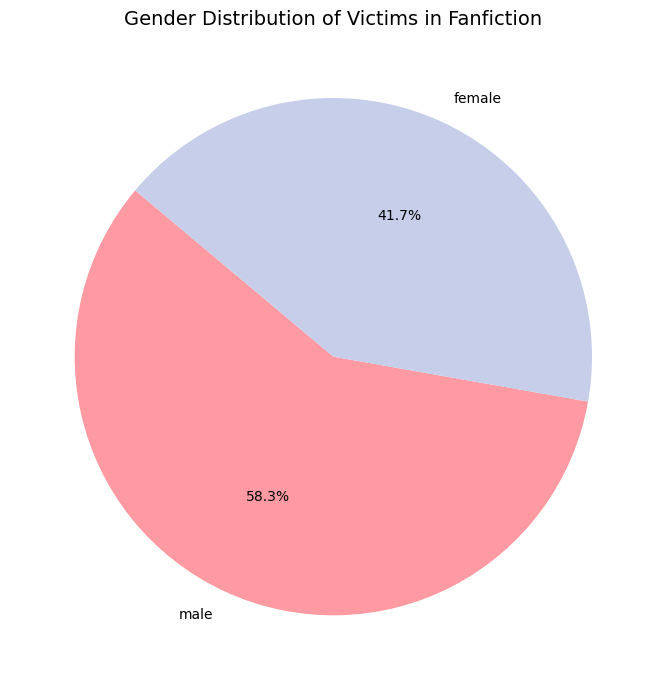

In [37]:
# Visualization: Gender distribution pie chart
plt.figure(figsize=(7, 7))
plt.pie(df_gender["Victim Count"], labels=df_gender["Gender"],
        autopct="%1.1f%%", startangle=140,
        colors=["#FF9AA2", "#C7CEEA", "#B5EAD7", "#FFDAC1"])
plt.title("Gender Distribution of Victims in Fanfiction", fontsize=14)
plt.tight_layout()
plt.show()

### 2.6 Most Frequently Killed Character (CQ6)
Who is the most frequently killed character?

Counts how many distinct fanfiction stories each character appears in as a victim, filtered to English labels and limited to the top 5.

In [38]:
# CQ6: Most frequently killed character (top 5)
sparql_query_2_6 = """
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX dlp: <http://www.ontologydesignpatterns.org/ont/dlp/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX gt: <https://data.golemlab.eu/entity/type/>
PREFIX schema: <https://schema.org/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>

SELECT ?victimLabel (COUNT(DISTINCT ?story) AS ?appearanceCount)
WHERE {
  GRAPH <https://golemlab.eu/graph/Greek10_Character_Module_Demo> {
    # Find fanfiction stories
    ?story a lrm:F1 ;
           crm:P2_has_type gt:T000000014 .   # fanFiction
    
    # Find victim characters in these stories
    ?victim dlp:plays gd:NR00000001 ;         # victim role
            gc:GP1_is_character_in ?story ;
            crm:P130_shows_features_of ?characterStoff ;
            skos:prefLabel ?victimLabel .
    
    # Get victim role label
    gd:NR00000001 skos:prefLabel ?victimRoleLabel .
    
    FILTER(LANG(?victimLabel) = "en")
  }
}
GROUP BY ?victimLabel
ORDER BY DESC(?appearanceCount)
LIMIT 5
"""

sparql.setQuery(sparql_query_2_6)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data = []
for result in results["results"]["bindings"]:
    data.append({
        "Character": result["victimLabel"]["value"],
        "Death Count": int(result["appearanceCount"]["value"])
    })

df_most_killed = pd.DataFrame(data)
print("\nMost Frequently Killed Characters:")
df_most_killed


Most Frequently Killed Characters:


,Character,Death Count
0,Hector,2
1,Semele,1
2,Persephone,1
3,Paris,1
4,Ajax,1


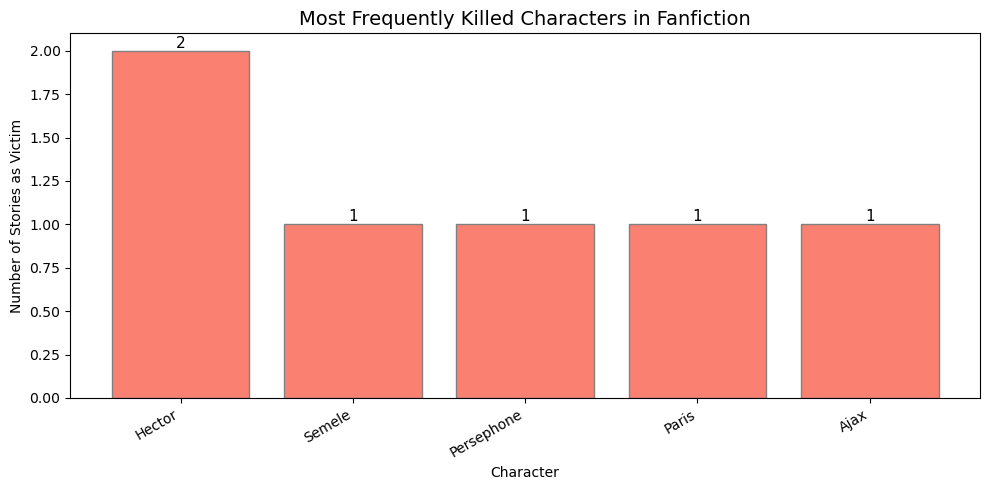

In [39]:
# Visualization: Bar chart of most killed characters
plt.figure(figsize=(10, 5))
bars = plt.bar(df_most_killed["Character"], df_most_killed["Death Count"],
               color="salmon", edgecolor="grey")
plt.title("Most Frequently Killed Characters in Fanfiction", fontsize=14)
plt.xlabel("Character")
plt.ylabel("Number of Stories as Victim")
plt.xticks(rotation=30, ha="right")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             str(int(bar.get_height())), ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

### 2.7 Biographical Features of the Most-Killed Character (CQ7)
What biographical details does the most-killed character have?

Using the Stoff identifier `gd:C000000264` (Hector), this query retrieves all features classified as biographical (`gt:BIO0000000`) from fanfiction works.

In [40]:
# CQ7: Biographical features of Hector in fanfiction
sparql_query_2_7 = """
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX gt: <https://data.golemlab.eu/entity/type/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>

SELECT DISTINCT ?featureLabel ?featureTypeLabel
WHERE {
  GRAPH <https://golemlab.eu/graph/Greek10_Character_Module_Demo> {
    # Find Hector in fanfiction via Stoff
    ?character crm:P130_shows_features_of gd:C000000264 ;
               gc:GP1_is_character_in ?story .
    
    # Get features of biography type (gt:BIO0000000)
    ?feature gc:GP0i_is_feature_of ?character ;
             crm:P2_has_type gt:BIO0000000 ;
             skos:prefLabel ?featureLabel .
    
    gt:BIO0000000 skos:prefLabel ?featureTypeLabel .
    
    # Limit to fanfiction
    ?story a lrm:F1 ;
           crm:P2_has_type gt:T000000014 .   # fanFiction
    
    FILTER(LANG(?featureLabel) = "en")
  }
}
"""

sparql.setQuery(sparql_query_2_7)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data = []
for result in results["results"]["bindings"]:
    data.append({
        "Feature": result["featureLabel"]["value"],
        "Feature Type": result["featureTypeLabel"]["value"]
    })

df_bio = pd.DataFrame(data)
print("\nBiographical Features of Hector (Fanfiction):")
df_bio


Biographical Features of Hector (Fanfiction):


,Feature,Feature Type
0,warrior,Biography
1,male,Biography
2,prince of Troy,Biography
3,noble warrior,Biography


### 2.8 Physical Description in Canon (CQ8)
How is the character physically described in canon?

This query retrieves physical features (`gt:PHY0000000`) for Hector (`gd:C000000264`) from canonical works (`gt:T0000000013`).

In [41]:
# CQ8: Physical features of Hector in canon
sparql_query_2_8 = """
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX gt: <https://data.golemlab.eu/entity/type/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>

SELECT DISTINCT ?featureLabel ?featureTypeLabel
WHERE {
  GRAPH <https://golemlab.eu/graph/Greek10_Character_Module_Demo> {
    # Find canon Hector instance
    ?character crm:P130_shows_features_of gd:C000000264 ;
               gc:GP1_is_character_in ?canonWork .
    
    # Get physical features
    ?feature gc:GP0i_is_feature_of ?character ;
             crm:P2_has_type gt:PHY0000000 ;
             skos:prefLabel ?featureLabel .
    
    gt:PHY0000000 skos:prefLabel ?featureTypeLabel .
    
    ?canonWork crm:P2_has_type gt:T0000000013 .
    
    FILTER(LANG(?featureLabel) = "en")
  }
}
"""

sparql.setQuery(sparql_query_2_8)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data = []
for result in results["results"]["bindings"]:
    data.append({
        "Feature": result["featureLabel"]["value"],
        "Feature Type": result["featureTypeLabel"]["value"]
    })

df_physical = pd.DataFrame(data)
print("\nPhysical Features of Hector (Canon):")
df_physical


Physical Features of Hector (Canon):


,Feature,Feature Type
0,tall and strong,Physical Description
1,wears shining armor,Physical Description


### 2.9 Psychological / Emotional Features in Fanfiction (CQ9)
What emotions does the character exhibit in fanfiction?

Retrieves psychological features (`gt:PSY0000000`) for Hector from fanfiction works using the character's `skos:prefLabel` and `gc:GP0_has_feature` property.

In [42]:
# CQ9: Psychological/emotional features of Hector in fanfiction
sparql_query_2_9 = """
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX gt: <https://data.golemlab.eu/entity/type/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>

SELECT DISTINCT ?featureLabel ?featureTypeLabel
WHERE {
  GRAPH <https://golemlab.eu/graph/Greek10_Character_Module_Demo> {
    # Find Hector in fanfiction
    ?character gc:GP1_is_character_in ?story ;
               skos:prefLabel "Hector"@en ;
               gc:GP0_has_feature ?feature .
    
    # Get psychological features (gt:PSY0000000)
    ?feature crm:P2_has_type gt:PSY0000000 ;
             skos:prefLabel ?featureLabel .
    
    gt:PSY0000000 skos:prefLabel ?featureTypeLabel .
    
    # Limit to fanfiction stories
    ?story a lrm:F1 ;
           crm:P2_has_type gt:T000000014 .   # fanFiction
    
    FILTER(LANG(?featureLabel) = "en")
  }
}
"""

sparql.setQuery(sparql_query_2_9)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data = []
for result in results["results"]["bindings"]:
    data.append({
        "Feature": result["featureLabel"]["value"],
        "Feature Type": result["featureTypeLabel"]["value"]
    })

df_psych = pd.DataFrame(data)
print("\nPsychological Features of Hector (Fanfiction):")
df_psych


Psychological Features of Hector (Fanfiction):


,Feature,Feature Type
0,kind,Psychological Description
1,loves but resents Paris,Psychological Description
2,honorable,Psychological Description
3,conflicted emotions,Psychological Description
4,treats Helen with dignity,Psychological Description


### 2.10 Cause of Death: Canon vs. Fanfiction (CQ10)
How does the cause of death differ between canon and fanfiction?

This query compares narrative events (`gc:G5_Narrative_Event`) where Hector plays the victim role in canonical works versus fanfiction works, using `dlp:participant-in` to link character instances to their death events.

In [43]:
# CQ10: Compare Hector's cause of death in canon vs. fanfiction
sparql_query_2_10 = """
PREFIX gc: <https://ontology.golemlab.eu/>
PREFIX gd: <https://data.golemlab.eu/entity/>
PREFIX dlp: <http://www.ontologydesignpatterns.org/ont/dlp/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX gt: <https://data.golemlab.eu/entity/type/>
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX schema: <https://schema.org/>

SELECT DISTINCT ?canonWorkTitle ?canonDeathEvent ?fanficWorkTitle ?fanficDeathEvent
WHERE {
  GRAPH <https://golemlab.eu/graph/Greek10_Character_Module_Demo> {
    # Canon part
    {
      ?canonWork a lrm:F1 ;
                 crm:P2_has_type gt:T0000000013 ;
                 schema:title ?canonWorkTitle .
      ?hectorCanon crm:P130_shows_features_of gd:C000000264 ;
                   gc:GP1_is_character_in ?canonWork ;
                   dlp:participant-in ?canonEvent ;
                   dlp:plays gd:NR00000001 .
      ?canonEvent a gc:G5_Narrative_Event ;
                  skos:prefLabel ?canonDeathEvent .
    }
    # Fanfiction part
    {
      ?fanficWork a lrm:F1 ;
                  crm:P2_has_type gt:T000000014 ;
                  schema:title ?fanficWorkTitle .
      ?hectorFanfic crm:P130_shows_features_of gd:C000000264 ;
                    gc:GP1_is_character_in ?fanficWork ;
                    dlp:participant-in ?fanficEvent ;
                    dlp:plays gd:NR00000001 .
      ?fanficEvent a gc:G5_Narrative_Event ;
                   skos:prefLabel ?fanficDeathEvent .
    }
  }
}
"""

sparql.setQuery(sparql_query_2_10)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data = []
for result in results["results"]["bindings"]:
    data.append({
        "Canon Work": result.get("canonWorkTitle", {}).get("value", "N/A"),
        "Canon Death Event": result.get("canonDeathEvent", {}).get("value", "N/A"),
        "Fanfic Work": result.get("fanficWorkTitle", {}).get("value", "N/A"),
        "Fanfic Death Event": result.get("fanficDeathEvent", {}).get("value", "N/A")
    })

df_death_comparison = pd.DataFrame(data)
print("\nComparison of Hector\'s Death in Canon vs. Fanfiction:")
df_death_comparison


Comparison of Hector's Death in Canon vs. Fanfiction:


,Canon Work,Canon Death Event,Fanfic Work,Fanfic Death Event
0,Homeric Iliad (Canon),Achilles kills Hector in revenge,The Face That—,Achilles strikes Hector down in battle.
1,Homeric Iliad (Canon),Achilles kills Hector in revenge,Requiem,Achilles kills Hector in battle.
2,Homeric Iliad (Canon),Achilles kills Hector in revenge,The Face That—,Achilles drags Hector's corpse behind his char...
3,Homeric Iliad (Canon),Achilles kills Hector in revenge,Requiem,Hector kills Patroclus.
4,Homeric Iliad (Canon),Hector kills Patroclus,The Face That—,Achilles strikes Hector down in battle.
5,Homeric Iliad (Canon),Hector kills Patroclus,Requiem,Achilles kills Hector in battle.
6,Homeric Iliad (Canon),Hector kills Patroclus,Requiem,Hector kills Patroclus.
7,Homeric Iliad (Canon),Hector kills Patroclus,The Face That—,Achilles drags Hector's corpse behind his char...
